In [34]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import boxcox

#### Full model summary

In [35]:
#Load model-ready data
df = pd.read_csv("kidney_disease_model_ready.csv")

# Define response variable
y = df["sc"]  # serum creatinine

#Build full predictor matrix drop response
X_full = df.drop(columns=["sc"])

#Add intercept and fit FULL model
X_full_const = sm.add_constant(X_full)
full_model = sm.OLS(y, X_full_const).fit()

print(full_model.summary())
params = full_model.params  
equation = "sc_hat = "




                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     41.11
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           1.46e-49
Time:                        18:26:17   Log-Likelihood:                -236.48
No. Observations:                 158   AIC:                             521.0
Df Residuals:                     134   BIC:                             594.5
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -10.8754     30.675     -0.355      

In [36]:
df['al'].value_counts()


al
0.000000    116
4.000000     15
3.000000     15
2.000000      9
1.000000      3
Name: count, dtype: int64

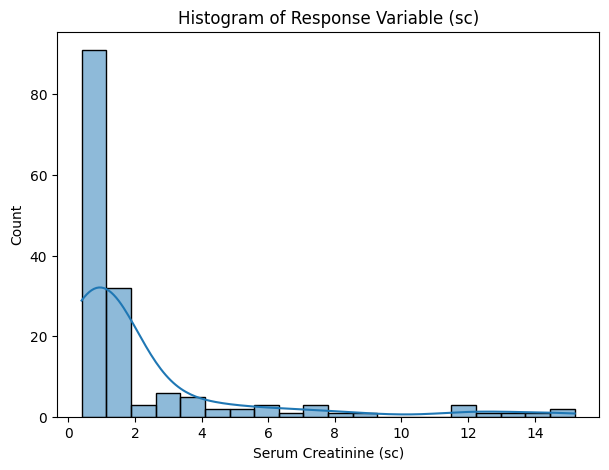

In [37]:
# Histogram of serum creatinine (sc)
plt.figure(figsize=(7,5))
sns.histplot(df["sc"], kde=True, bins=20)
plt.xlabel("Serum Creatinine (sc)")
plt.title("Histogram of Response Variable (sc)")
plt.show()

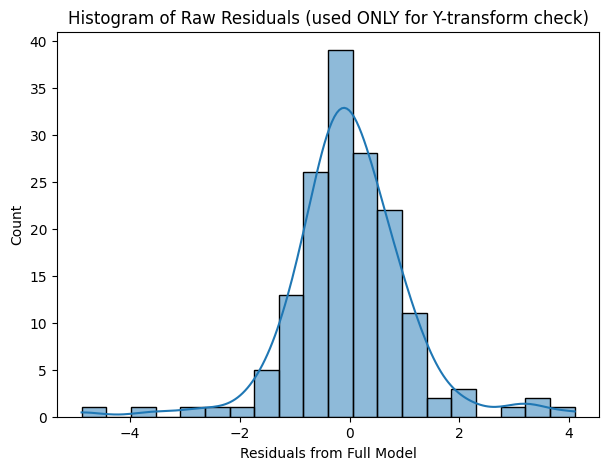

In [38]:
# Raw residuals of full model
resid_full = full_model.resid

plt.figure(figsize=(7,5))
sns.histplot(resid_full, kde=True, bins=20)
plt.xlabel("Residuals from Full Model")
plt.title("Histogram of Raw Residuals (used ONLY for Y-transform check)")
plt.show()

In [39]:

y_bc, lambda_opt = boxcox(df["sc"])
print("Optimal Box-Cox lambda:", lambda_opt)

Optimal Box-Cox lambda: -0.7108624125483377


In [40]:
# ===== 4. Full-model coefficients + p-values (clean table) =====
full_model = sm.OLS(y, sm.add_constant(X_full)).fit()

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print("\nFULL MODEL: Coefficients and P-Values (sorted by p-value)\n")

# Build table
coef_table = pd.DataFrame({
    "feature": full_model.params.index,
    "coefficient": full_model.params.values,
    "p_value": full_model.pvalues.values
})

# Remove intercept for sorting (add back later)
coef_no_const = coef_table[coef_table["feature"] != "const"].copy()
coef_no_const = coef_no_const.sort_values("p_value")

# Reinsert intercept at the top
intercept_row = coef_table[coef_table["feature"] == "const"]
coef_final_table = pd.concat([intercept_row, coef_no_const], ignore_index=True)

# Reset index starting from 1
coef_final_table.index = coef_final_table.index + 1

# Print it nicely
print(coef_final_table.to_string(index=True, float_format=lambda x: f'{x:.6f}'))


# ===== 5. VIF table for final selected model =====
print("\nVIF for final model (last run):")
X_final = X_full[final_vars]  
vif_final = compute_vif(X_final)
print(vif_final)



FULL MODEL: Coefficients and P-Values (sorted by p-value)

        feature  coefficient  p_value
1         const   -10.875428 0.723495
2            bu     0.039438 0.000000
3           pot    -0.119653 0.000673
4            al     0.457589 0.004637
5        pe_yes     1.521768 0.006225
6            wc    -0.000099 0.007801
7       ane_yes     1.205547 0.035166
8     pc_normal     1.026633 0.040628
9    appet_poor    -0.897803 0.061572
10           bp     0.018922 0.065111
11   ba_present    -0.908200 0.083435
12           rc    -0.237439 0.131206
13          pcv    -0.033166 0.171352
14   rbc_normal    -0.559063 0.224490
15           su     0.246326 0.252530
16         hemo    -0.084673 0.263943
17  pcc_present    -0.482598 0.341343
18          bgr    -0.002121 0.439172
19      htn_yes    -0.258496 0.634915
20           sg    13.968683 0.648456
21          age    -0.002976 0.662654
22      cad_yes    -0.143627 0.778708
23          sod     0.000512 0.977711
24       dm_yes     0.005316

#### VIF Table

In [41]:
vif_data = []
for i in range(X_vif.shape[1]):
    vif = variance_inflation_factor(X_vif.values, i)
    vif_data.append({"feature": X_vif.columns[i], "VIF": vif})

vif_df = pd.DataFrame(vif_data)
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

# Make index start from 1 instead of 0
vif_df.index = vif_df.index + 1

print(vif_df)


NameError: name 'X_vif' is not defined

#### Full model predictors and pvalues

In [ ]:
# 8. Get all p-values from the full model, printed without scientific notation
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print("\n===== P-VALUES (sorted, non-scientific) =====")
pvals_all_sorted = full_model.pvalues.sort_values()

# Create a numbered index starting from 1
pvals_numbered = pvals_all_sorted.reset_index()
pvals_numbered.index = pvals_numbered.index + 1
pvals_numbered.columns = ["feature", "p_value"]

# Print nicely formatted
print(pvals_numbered.to_string(index=True, float_format=lambda x: f'{x:.6f}'))



P-VALUES (sorted)
        feature  p_value
1            bu 0.000000
2           pot 0.000673
3            al 0.004637
4        pe_yes 0.006225
5            wc 0.007801
6       ane_yes 0.035166
7     pc_normal 0.040628
8    appet_poor 0.061572
9            bp 0.065111
10   ba_present 0.083435
11           rc 0.131206
12          pcv 0.171352
13   rbc_normal 0.224490
14           su 0.252530
15         hemo 0.263943
16  pcc_present 0.341343
17          bgr 0.439172
18      htn_yes 0.634915
19           sg 0.648456
20          age 0.662654
21        const 0.723495
22      cad_yes 0.778708
23          sod 0.977711
24       dm_yes 0.992364


#### Reduced Model Predictors

In [ ]:
# 1. Get all p-values from full model (excluding intercept)
pvals = full_model.pvalues.drop("const")

# 2. Select predictors with p < 0.05
reduced_predictors = pvals[pvals < 0.05].index.tolist()

print(reduced_predictors)


['al', 'bu', 'pot', 'wc', 'pc_normal', 'pe_yes', 'ane_yes']


#### Reduced Model Summary using Backward Elmination

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ===== 1. Helper: VIF computation =====
def compute_vif(X):
    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_df

# ===== 2. Combined Backward Elimination + VIF constraint =====
def backward_elimination_with_vif(X, y, alpha=0.05, vif_thresh=10, verbose=False):
    """
    Combined backward elimination + VIF constraint.
    Removes predictor with:
        1) VIF > vif_thresh (highest VIF goes first)
        2) otherwise: highest p-value > alpha
    Continues until both p-values and VIFs meet criteria.
    """
    X_current = X.copy()
    removed = []
    step = 0

    while True:
        X_const = sm.add_constant(X_current)
        model = sm.OLS(y, X_const).fit()

        # 1) Check VIFs
        vif_df = compute_vif(X_current)
        high_vif = vif_df[vif_df["VIF"] > vif_thresh]

        if not high_vif.empty:
            # remove variable with highest VIF
            worst_row = high_vif.sort_values("VIF", ascending=False).iloc[0]
            worst_var = worst_row["feature"]
            worst_vif = worst_row["VIF"]

            removed.append((worst_var, f"VIF={worst_vif:.2f}"))
            if verbose:
                print(f"Step {step}: Removing '{worst_var}' due to HIGH VIF = {worst_vif:.2f}")

            X_current = X_current.drop(columns=[worst_var])
            step += 1
            continue

        # 2) If VIFs okay, do p-value based backward elimination
        pvals = model.pvalues.drop("const")
        worst_p = pvals.max()
        worst_p_var = pvals.idxmax()

        # stop criterion: all p-values < alpha and all VIFs < threshold
        if worst_p < alpha:
            if verbose:
                print("\nAll predictors meet p-value and VIF criteria.")
            break

        removed.append((worst_p_var, f"p={worst_p:.4f}"))
        if verbose:
            print(f"Step {step}: Removing '{worst_p_var}' due to HIGH p-value = {worst_p:.4f}")

        X_current = X_current.drop(columns=[worst_p_var])
        step += 1

    return removed, list(X_current.columns)

# ===== 3. Run multiple times with shuffled column orders to check stability =====
n_runs = 10
alpha = 0.05
vif_thresh = 10

final_sets = []

for r in range(n_runs):
    # shuffle predictor order
    X_shuffled = X_full.sample(frac=1, axis=1, random_state=r)

    removed_vars, final_vars = backward_elimination_with_vif(
        X_shuffled, y, alpha=alpha, vif_thresh=vif_thresh, verbose=False
    )

    final_sorted = tuple(sorted(final_vars))
    final_sets.append(final_sorted)
    print(f"Run {r}: final predictors ({len(final_vars)} vars) -> {final_sorted}")

# Unique final models across runs
unique_final_sets = set(final_sets)
print("\nNumber of unique final predictor sets across runs:", len(unique_final_sets))
for s in unique_final_sets:
    print("  ", s)

# ===== 4. Full-model coefficients + p-values (clean table) =====
full_model = sm.OLS(y, sm.add_constant(X_full)).fit()

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print("\nFULL MODEL: Coefficients and P-Values (sorted by p-value)\n")

coef_table = pd.DataFrame({
    "feature": full_model.params.index,
    "coefficient": full_model.params.values,
    "p_value": full_model.pvalues.values
})

# Separate intercept, sort others by p-value
intercept_row = coef_table[coef_table["feature"] == "const"]
coef_no_const = coef_table[coef_table["feature"] != "const"].copy()
coef_no_const = coef_no_const.sort_values("p_value")

coef_final_table = pd.concat([intercept_row, coef_no_const], ignore_index=True)
coef_final_table.index = coef_final_table.index + 1

print(coef_final_table.to_string(index=True, float_format=lambda x: f'{x:.6f}'))

# ===== 5. VIF table for the final selected model =====
print("\nVIF for final selected model (last run):")
X_final = X_full[final_vars]  # uses final_vars from last run of the loop
vif_final = compute_vif(X_final)
print(vif_final)


Run 0: final predictors (7 vars) -> ('al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc')
Run 1: final predictors (7 vars) -> ('al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc')
Run 2: final predictors (7 vars) -> ('al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc')
Run 3: final predictors (7 vars) -> ('al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc')
Run 4: final predictors (7 vars) -> ('al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc')
Run 5: final predictors (7 vars) -> ('al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc')
Run 6: final predictors (7 vars) -> ('al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc')
Run 7: final predictors (7 vars) -> ('al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc')
Run 8: final predictors (7 vars) -> ('al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc')
Run 9: final predictors (7 vars) -> ('al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc')

Number of unique fi

In [42]:
import statsmodels.api as sm

# Final predictors you obtained from backward elimination
predictors_final = ['al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc']

# X and y
X_reduced = df[predictors_final]
y = df['sc']  # your response variable

# Add intercept
X_reduced = sm.add_constant(X_reduced)

# Fit reduced model
reduced_model = sm.OLS(y, X_reduced).fit()

# Print summary
print(reduced_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     123.2
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           6.60e-59
Time:                        18:27:15   Log-Likelihood:                -250.45
No. Observations:                 158   AIC:                             516.9
Df Residuals:                     150   BIC:                             541.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.4334      0.357      1.212      

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Your final predictor list
predictors_final = ['al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc']

# Build reduced X without intercept
X_reduced_vif = X_full[predictors_final]

# Compute VIF
vif_data = []
for i in range(X_reduced_vif.shape[1]):
    vif = variance_inflation_factor(X_reduced_vif.values, i)
    vif_data.append({"feature": X_reduced_vif.columns[i], "VIF": vif})

vif_df = pd.DataFrame(vif_data)

print("\n===== VIF for Reduced Model Predictors =====")
print(vif_df)



===== VIF for Reduced Model Predictors =====
       feature      VIF
0           al 3.270957
1      ane_yes 2.225405
2           bu 4.963798
3  pcc_present 1.652715
4       pe_yes 2.154418
5          pot 2.690243
6           wc 2.920653


#### ANOVA Test Comparing Both Models

In [46]:
from statsmodels.stats.anova import anova_lm
#hypothesis test
print("\n=== Hypothesis Test for Model Reduction ===")
print("H0: The reduced model is adequate; the removed predictors do NOT improve model fit.")
print("H1: The full model fits significantly better than the reduced model.")

anova_results = anova_lm(reduced_model, full_model)

#ANOVA results
print(anova_results)

# Extract p-value for the F-test comparing reduced vs full
# Row 0 = reduced model, Row 1 = full model
pval = anova_results["Pr(>F)"].iloc[1]
alpha = 0.05

print(f"\nANOVA p-value: {pval:.4f}")

if pval > alpha:
    print(f"Since p-value = {pval:.4f} > {alpha}, we FAIL to reject H0.")
    print("→ Conclusion: The reduced model is sufficient; we can keep the simpler model.")
else:
    print(f"Since p-value = {pval:.4f} ≤ {alpha}, we REJECT H0.")
    print("→ Conclusion: The full model is significantly better; we should use the full model.")



=== Hypothesis Test for Model Reduction ===
H0: The reduced model is adequate; the removed predictors do NOT improve model fit.
H1: The full model fits significantly better than the reduced model.
    df_resid        ssr   df_diff   ss_diff        F   Pr(>F)
0 150.000000 220.288809  0.000000       NaN      NaN      NaN
1 134.000000 184.579206 16.000000 35.709603 1.620269 0.071501

ANOVA p-value: 0.0715
Since p-value = 0.0715 > 0.05, we FAIL to reject H0.
→ Conclusion: The reduced model is sufficient; we can keep the simpler model.


In [65]:
import statsmodels.api as sm

# Final predictors
predictors_final = ['al', 'ane_yes', 'bu', 'pcc_present', 'pe_yes', 'pot', 'wc']

# Build reduced model
X_reduced = df[predictors_final]
y = df['sc']

X_reduced = sm.add_constant(X_reduced)
reduced_model = sm.OLS(y, X_reduced).fit()

print("===== Standard OLS Model =====")
print(reduced_model.summary())

# Robust HC3 model
print("\n===== Robust (HC3) Standard Errors =====")
reduced_model_robust = reduced_model.get_robustcov_results(cov_type='HC3')
print(reduced_model_robust.summary())

print(reduced_model_robust.model.exog_names)



===== Standard OLS Model =====
                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     123.2
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           6.60e-59
Time:                        18:41:21   Log-Likelihood:                -250.45
No. Observations:                 158   AIC:                             516.9
Df Residuals:                     150   BIC:                             541.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.4

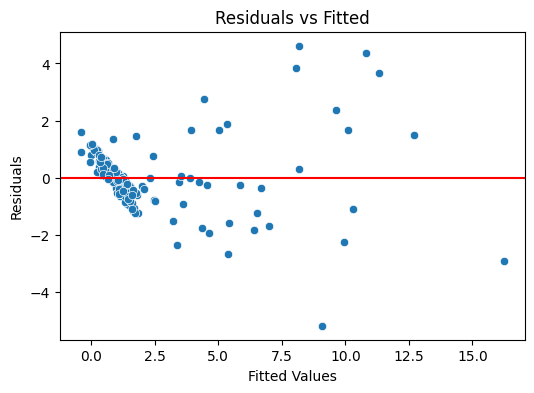

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

resid = reduced_model_robust.resid
fitted = reduced_model_robust.fittedvalues

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()


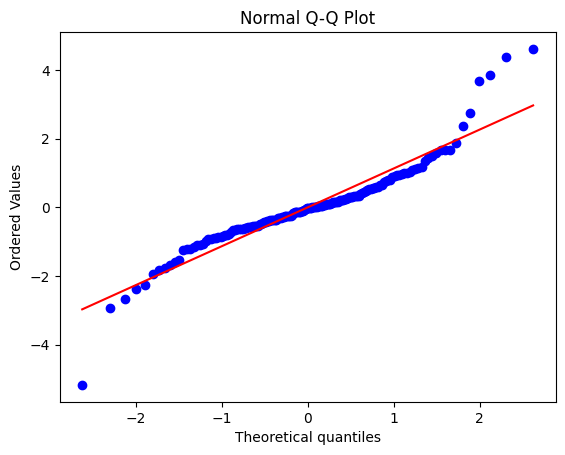

In [61]:
import scipy.stats as stats

stats.probplot(resid, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()


In [62]:
#Influencial Analysis values 
influence = reduced_model.get_influence()
studentized_resid = influence.resid_studentized_external
hat_values = influence.hat_matrix_diag
cooks_d, _ = influence.cooks_distance

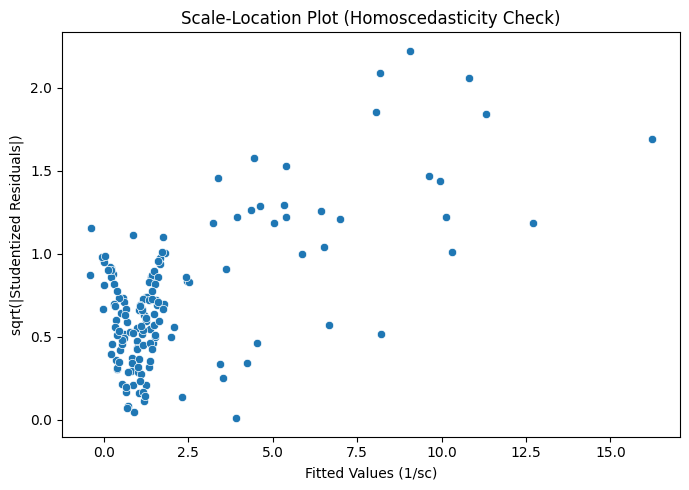

In [63]:
# Scale location plot
plt.figure(figsize=(7,5))
sqrt_abs_sr = np.sqrt(np.abs(studentized_resid))
sns.scatterplot(x=fitted, y=sqrt_abs_sr)
plt.xlabel("Fitted Values (1/sc)")
plt.ylabel("sqrt(|Studentized Residuals|)")
plt.title("Scale-Location Plot (Homoscedasticity Check)")
plt.tight_layout()
plt.show()